# To do
- Make bin size smaller (currently 100 ms, try 50 ms)
- CI instead of SEM
- Check usage of labels vs probabilities for predictions accuracy
- Remove misses from analysis! (done in within decoder and epoch cross decoder)
- Use only single units vs MUA
- Cortical neurons (depth < 1.5 mm) vs deep neurons (depth > 1.5 mm)

From meeting with Jaime:
Alexis, remember to make a summary bullet lists from yesterday’s meeting. I think it was quite productive and I feel we have a more clear idea of what to do.
I was thinking a bit more about decoding the stimulus or the choice. Perhaps one way to make it simpler is to:
- Train with ALL engaged trials (correct and error) on
    - predicting the stimulus in stim epoch (Stim Code)
    - predicting the choice in Delay epoch (Delay Code)
    - predicting the choice in licking epoch (Response Code).
I think by combining correct and error trials in the training, it is possible that the Stim Code is not as contaminated by persistent neurons as when you only use correct trials (because in correct trials Stim and choice always match!).
- If you train with all engaged trials using k-fold, you can later compute the decoding accuracy separately for correct and error (engaged) trials by simply separating them in the testing set.

- From Inagaki et al 2022 (MEthods ‘Coding Direction Analusys’), we should take the computation of the Ramp Mode (they call it D_ramp) and the Go Mode (D_Go). In the methods they describe how to compute them. They do not train decoders but simply compute the population vector difference between two average conditions. That gives you a direction vector in the n-space D_X where you can project the activity of the population at any time point of any trial. They kind of cross-validate by computing the direction vector with some trials (training) and projecting some others (testing). But you could apply the same idea of D_ramp and D_Go using the decoders approach:
    - For D_ramp you have to train a decoder to distinguish from population activity two categories: pre-stim vs delay. Each trial contributes therefore with two samples (pre-stim and delay; unlike when training for choice or stim where each trial is always one sample). We will need to think the consequences of this within-trial link between pairs of samples when doing CV.
    - Once you train your pre-stim VS delay decoder, you don’t want to plot the trace of the accuracy because it can be high both in pre-stim and delay epochs, but the prob(decoder says ‘delay’). This prob should go from values under 0.5 in pre-stim epoch to above 0.5 in the delay epoch. Makes sense?

There are some qualitative differences with what you may be finding:
- They see a very clear difference between the Delay code in Right vs Left trials and which corresponds to Contra and Ipsi, resp (they aways record in the Left hemisphere). You could check this by computing the decoder accuracy separately for contra vs ipsi trials (because you do have recordings from the two hemispheres, right?)
- They also see this prestimulus decoding of the stimulus in error trials. It is not clear to me yet, whether this is artifact del slow drift of the neural activity or it is physiological (i.e. there is an imbalance in the activity of choice neurons before the stimulus that generates the error) but it is something which would be worth looking in detail.
- Finally, the see that in miss trials, there are not Lick decoding (obvious), the Delay ramp is lower and the Go mode is there but also kind of lower. They probably have very few miss trials and things look noisy, but still, they have already done quite a bit in this regard.

Jaime, I agree that yesterday was a very productive meeting. This is what I have in my notes, please add anything I might have forgotten:
- Clean neurons that dissappear
    - FR < 1 spike/s --> Remove
    - Use valid trials to compute for every neuron:  var(FR) / mean(FR) per trial. Plot distribution and play with threshold to remove outliers at the tails
- Re-read Ashwood 2022, check where they compare the RTs across states if there're differences
- Cross time decoder:
    - Thinner lines, left align to bin edges
    - Draw horizontal lines -slices- from where sampling later the training epoch for the epoch decoders (stim, delay, response)
- Check code overlap in Tiffany's paper (significance expected between stimulus and delay but not between delay and response)
- Small bump in response code of epoch decoder could be anticipatory licks (to the air) or motor getting stuck in some trials
    - Test hypothesis by removing aberrant licks (licks that happen before response window opens) or by removing those trials and checking if the small bump dissappear
- Repeat analyses but predicitng choice instead of stimulus side (that should make the downward in error trials become mirrored but positive)
- Study Inagaki's and Svoboda's works because they're becoming even more relvant:
    - Thalamus-driven functional populations in frontal cortex support decision-making
    - A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement

In [1]:
import numpy as np
# Magics
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')  # Resets to standard white background
import seaborn as sns
sns.set_theme()
sns.set_style('ticks')
sns.set_context('talk')
from ephys.decoder import *

Processing session 1/13: 007_2024-06-22_10-48-57...
Files exist in folder. Skipping
Processing session 2/13: 007_2024-06-23_12-46-55...
Files exist in folder. Skipping
Processing session 3/13: 007_2024-06-24_17-47-22...
Files exist in folder. Skipping
Processing session 4/13: 007_2024-06-25_15-54-23...
Files exist in folder. Skipping
Processing session 5/13: 007_2024-06-26_15-19-30...
Files exist in folder. Skipping
Processing session 6/13: 007_2024-06-27_15-06-28...
Files exist in folder. Skipping
Processing session 7/13: 007_2024-06-28_14-18-51...
Files exist in folder. Skipping
Processing session 8/13: 007_2024-06-29_16-24-52...
Files exist in folder. Skipping
Processing session 9/13: 007_2024-07-08_12-20-29...
Files exist in folder. Skipping
Processing session 10/13: 007_2024-07-09_12-10-57...
Files exist in folder. Skipping
Processing session 11/13: 007_2024-07-10_12-03-35...
Files exist in folder. Skipping
Processing session 12/13: 007_2024-07-11_12-39-21...
Files exist in folder

# Load data

## Load spike counts

In [3]:
subject = '007'
folder_parent = Path.home() / 'data' / subject

ephys_ids = [
    '007_2024-06-22_10-48-57',
    '007_2024-06-23_12-46-55',
    '007_2024-06-24_17-47-22',
    '007_2024-06-25_15-54-23',
    '007_2024-06-26_15-19-30',
    '007_2024-06-27_15-06-28',
    '007_2024-06-28_14-18-51',
    '007_2024-06-29_16-24-52',
    # '007_2024-07-06_11-16-25',  # Bad session
    # '007_2024-07-07_13-20-29',  # Bad session
    '007_2024-07-08_12-20-29',
    '007_2024-07-09_12-10-57',
    '007_2024-07-10_12-03-35',
    '007_2024-07-11_12-39-21',
    '007_2024-07-12_13-29-26'  # ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1.
                                 # This happens because in correct disengaged trials the animal only responded right, so there's no left trials in labels
]

# Load spike counts for all neurons of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    print(f'Processing session {i + 1}/{len(ephys_ids)}: {ephys_ids[i]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Get spike counts
    if any(f.endswith('.npy') for f in os.listdir(folder_child)):
        print('Files exist in folder. Skipping')
        continue
    else:
        print('Files do not exist in folder. Proceeding')
        df_ttl, df_behavior, n_trials, df_spikes, cluster_info, x, height, labels, y, width, left, ts_edges, events_edges = \
            preprocess(ephys_ids[i])
        bins, all_psth = get_all_psth(cluster_info, df_spikes, df_ttl, n_trials, time_win=[-1, 3], bin_size=0.1)
    # Save bins and psth
    np.save(folder_child / 'bins.npy', bins)
    np.save(folder_child / 'all_psth.npy', all_psth)

Processing session 1/13: 007_2024-06-22_10-48-57...
Files exist in folder. Skipping
Processing session 2/13: 007_2024-06-23_12-46-55...
Files exist in folder. Skipping
Processing session 3/13: 007_2024-06-24_17-47-22...
Files exist in folder. Skipping
Processing session 4/13: 007_2024-06-25_15-54-23...
Files exist in folder. Skipping
Processing session 5/13: 007_2024-06-26_15-19-30...
Files exist in folder. Skipping
Processing session 6/13: 007_2024-06-27_15-06-28...
Files exist in folder. Skipping
Processing session 7/13: 007_2024-06-28_14-18-51...
Files exist in folder. Skipping
Processing session 8/13: 007_2024-06-29_16-24-52...
Files exist in folder. Skipping
Processing session 9/13: 007_2024-07-08_12-20-29...
Files exist in folder. Skipping
Processing session 10/13: 007_2024-07-09_12-10-57...
Files exist in folder. Skipping
Processing session 11/13: 007_2024-07-10_12-03-35...
Files exist in folder. Skipping
Processing session 12/13: 007_2024-07-11_12-39-21...
Files exist in folder

## Load behavior

In [4]:
# Load behavior of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    print(f'Parsing behavioral session {i + 1}/{len(ephys_ids)}: {filename[:-4]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Execute only if folder is empty
    if any(f.endswith('.csv') for f in os.listdir(folder_child)):
        print('File exist in folder. Skipping')
        continue
    else:
        print('File does not exist in folder. Proceeding')
        df_behavior = parse_v2(path_behavior)
        df_behavior.to_csv(folder_child / filename, index=False)


behavior = []
for i in range(len(ephys_ids)):
    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    folder_child = folder_parent / ephys_ids[i]
    df = pd.read_csv(folder_child / filename)
    behavior.append(df)

# # Get behavioral events
# stim_dur = df_behavior.StimDur.unique()[0]
# delay = df_behavior.Delay.unique()[0]
# go_cue = stim_dur + delay

Parsing behavioral session 1/13: 007_stage_training_v5_20240622-110354...
File exist in folder. Skipping
Parsing behavioral session 2/13: 007_stage_training_v5_20240623-130152...
File exist in folder. Skipping
Parsing behavioral session 3/13: 007_stage_training_v5_20240624-180217...
File exist in folder. Skipping
Parsing behavioral session 4/13: 007_stage_training_v5_20240625-160924...
File exist in folder. Skipping
Parsing behavioral session 5/13: 007_stage_training_v5_20240626-153431...
File exist in folder. Skipping
Parsing behavioral session 6/13: 007_stage_training_v5_20240627-152129...
File exist in folder. Skipping
Parsing behavioral session 7/13: 007_stage_training_v5_20240628-143350...
File exist in folder. Skipping
Parsing behavioral session 8/13: 007_stage_training_v5_20240629-163958...
File exist in folder. Skipping
Parsing behavioral session 9/13: 007_stage_training_v5_20240708-123523...
File exist in folder. Skipping
Parsing behavioral session 10/13: 007_stage_training_v5

### Find disengagement point and classify trials into engaged and disengaged

In [5]:
for i in range(len(behavior)):
    disengagement = find_disengaged(behavior[i], plot=False)  # Find trial when disengagement happens
    engaged = (behavior[i]['Trial'] <= disengagement).astype(int)  # Compare trials to disengagement (no need for i)
    behavior[i]['Engaged'] = engaged

Disengagement happened in trial 222
Disengagement happened in trial 293
Disengagement happened in trial 468
Disengagement happened in trial 240
Disengagement happened in trial 389
Disengagement happened in trial 283
Disengagement happened in trial 239
Disengagement happened in trial 335
Disengagement happened in trial 222
Disengagement happened in trial 220
Disengagement happened in trial 231
Disengagement happened in trial 220
Disengagement happened in trial 221


# Within Temporal Decoder (mean)

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
within_decoder took 1.92 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
within_decoder took 1.82 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
within_decoder took 2.66 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
within_decoder took 1.58 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
within_decoder took 2.10 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
within_decoder took 1.32 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
within_decoder took 1.78 seconds to run
Processing session 8/13: 007_2024-06-29_16-24-52...
Disengagement happened in trial 335
within_decoder t

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 3531 trials')

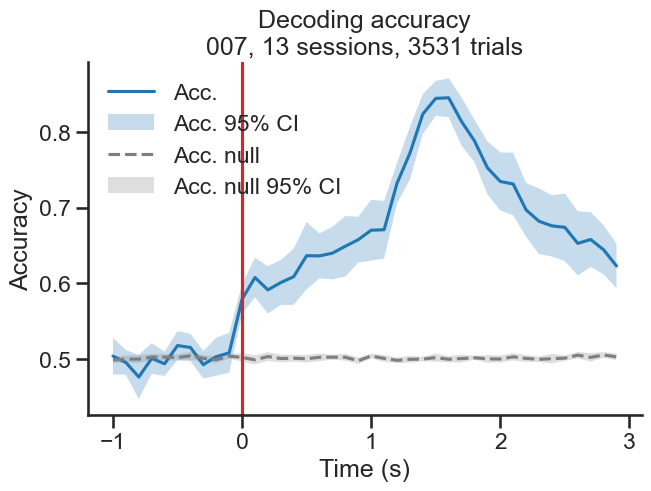

In [15]:
%%time
# Run mean within decoder across sessions
results = mean_decoder(kind='within', engagement=1, save=True)

# Load mean within decoder results across sessions
with open(Path(folder_parent / 'results_mean_within_decoder_engaged.pkl'), 'rb') as f:
    results = pickle.load(f)

# Plot mean within decoder results across sessions
plot_mean_within_decoder(results, z_null=False)
n_sessions = len(results['acc'])
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f"{subject}, {n_sessions} sessions, {n_trials} trials")

# Cross Temporal Decoder (mean)

CPU times: total: 93.8 ms
Wall time: 95 ms


Text(0.5, 1.0, 'Decoding accuracy\n 007, 13 sessions, 3596 trials')

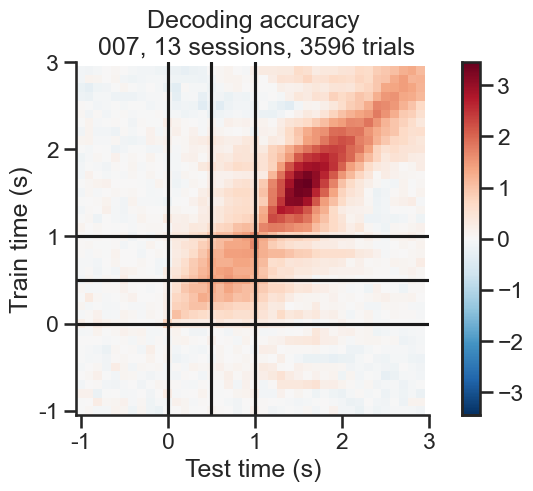

In [16]:
%%time
# Run mean cross decoder across sessions
# results = mean_decoder(kind='cross', engagement=1, save=True)

# Load mean cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_cross_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

# Plot mean within decoder results across sessions
plot_mean_cross_decoder(results, z_null=True)
n_sessions = len(results['acc'])
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f" {subject}, {n_sessions} sessions, {n_trials} trials")

To do:
- Thinner lines, align bins to the left (now they're centered)
- Horizontal lines showing the 'temporal slices' (stimulus, delay, go cue) corresponding to the epochs of interest in epoch cross decoder

# Epoch Cross Temporal Decoder (mean)

CPU times: total: 328 ms
Wall time: 321 ms


Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 3531 trials')

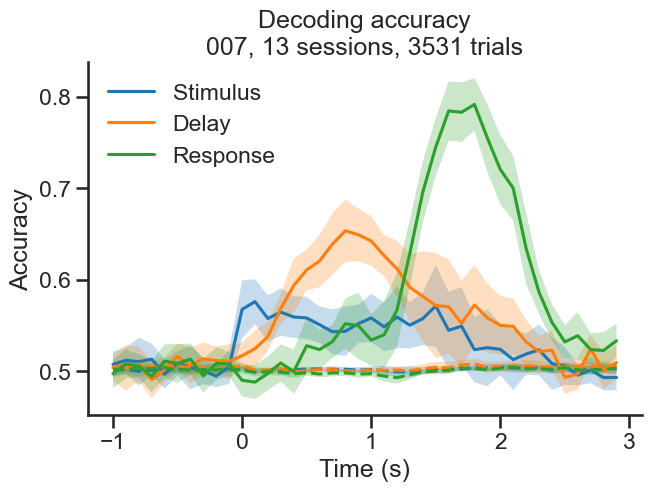

In [93]:
%%time
# Run mean epoch cross decoder across sessions
# results_stim = mean_decoder(kind='epoch', epoch='stim', engagement=1, save=True)
# results_delay = mean_decoder(kind='epoch', epoch='delay', engagement=1, save=True)
# results_resp = mean_decoder(kind='epoch', epoch='resp', engagement=1, save=True)

# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
    results_stim = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
    results_delay = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

To do:
- Code overlap between stim and delay in epoch cross decoder (see Tiffany's paper Fig. 3g)
- Small bump in response code could be anticipatory licking (licks to the air). It could also be the motor getting stuck in the previous trial and not going back, therefore representing aberrant licks (licks that shouldn't be there). Check if there are aberrant licks (licks before the response window opens), remove them and see if the small bump disappears.

## ORTHOGONALIZATION TEST: Epoch Cross Temporal Decoder (mean)

CPU times: total: 312 ms
Wall time: 307 ms


(0.45, 0.8)

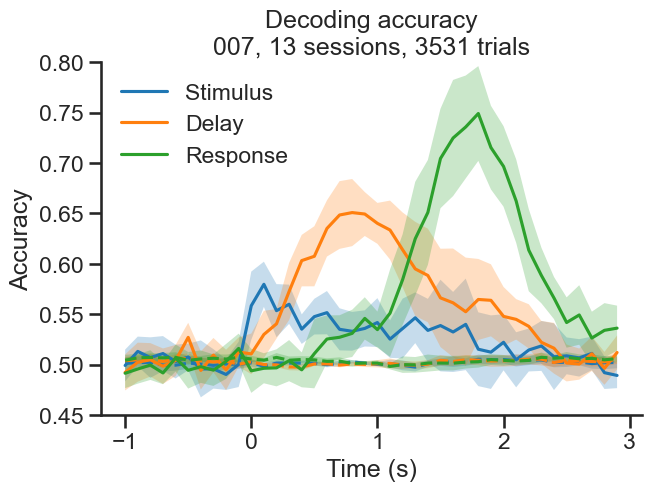

In [91]:
%%time
# Run mean epoch cross decoder across sessions
# results_stim = mean_decoder(kind='epoch_ortho', epoch='stim', epoch_ortho='delay', engagement=1, save=False)
# results_delay = mean_decoder(kind='epoch_ortho', epoch='delay', epoch_ortho='stim', engagement=1, save=False)
# results_resp = mean_decoder(kind='epoch_ortho', epoch='resp', epoch_ortho='delay', engagement=1, save=False)

# Load mean epoch cross decoder results across sessions
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
#     results_stim = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
#     results_delay = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
#     results_resp = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
Processing session 8/13: 007_2024-06-29_16-24-52...
Disengagement happened in trial 335
Processing session 9/13: 007_2024-07-08_12-20-29...
Disengagement happened in trial 222
Processing session 10/13: 007_2024-07-09_12-10-57...
Disengagement happened in trial 220
Processing session 11/13: 007_2024-07-10_12-03-35...
Disengagement happened in trial 231
Processing session 12/13: 007_

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 3531 trials')

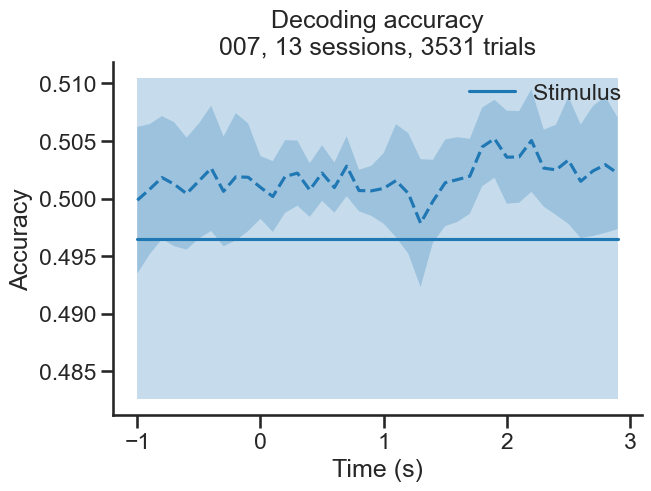

In [94]:
%%time
# Run mean epoch cross decoder across sessions
results_stim = mean_decoder(kind='epoch_ortho', epoch='stim', epoch_ortho='stim', engagement=1, save=False)
# results_delay = mean_decoder(kind='epoch_ortho', epoch='delay', epoch_ortho='stim', engagement=1, save=False)
# results_resp = mean_decoder(kind='epoch_ortho', epoch='resp', epoch_ortho='delay', engagement=1, save=False)

# Load mean epoch cross decoder results across sessions
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
#     results_stim = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
#     results_delay = pickle.load(f)
# with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
#     results_resp = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', errorbar='ci', z_null=False)
# plot_mean_epoch_cross_decoder(results_delay, epoch='delay', errorbar='ci', z_null=False)
# plot_mean_epoch_cross_decoder(results_resp, epoch='resp', errorbar='ci', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Epoch Cross Temporal Decoder Split (mean)

## Stimulus code split by Outcome (blue trace in mean epoch cross temporal decoder)
2 approaches that should lead to the same mean accuracy but **different** null accuracy:
1. Run the epoch cross decoder function above for all trials and then average across trial types according to split (e.g. splitting by outcome in correct/error trials). Mean null  accuracy should be the **same** for each split (flat at 0.5). This is **wrong**
2. Run the epoch cross decoder split function that performs the split when training the decoder. Mean null accuracy should be **different** for each split. This is **correct**

### 1. Run epoch cross decoder function for all trials and average across trial types

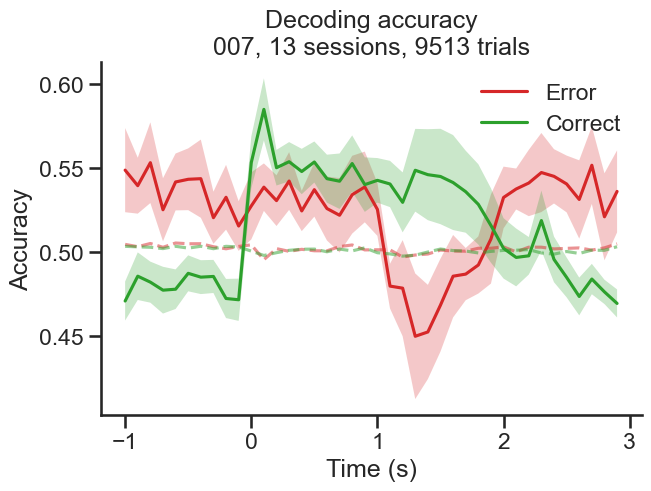

In [15]:
# Split stim decoder into correct vs error trials
# behavior = [behavior[i][behavior[i].Miss==0].reset_index(drop=True) for i in range(len(behavior))]
indexes = [get_trial_indexes(behavior[i], condition='outcome') for i in range(len(behavior))]
# indexes = [get_trial_indexes(behavior[i][behavior[i].Miss==0].reset_index(drop=True), condition='outcome') for i in range(len(behavior))]

# hits = [list(np.where(behavior[i].Hit == True)[0]) for i in range(len(behavior))]
# errors = [list(np.where(behavior[i].Hit == False)[0]) for i in range(len(behavior))]
# misses = [np.where(np.isnan(behavior[i].Hit))[0] for i in range(len(behavior))]
# indexes = [[h, e] for h, e in zip(hits, errors)]

# Error trials
acc_mean_error = [np.nanmean(results_stim['acc'][i][indexes[i][0]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_error = np.array(acc_mean_error)
acc_sem_error = sem(acc_mean_error, axis=0, nan_policy='omit')
acc_mean_error = np.mean(acc_mean_error, axis=0)
acc_null_mean_error = [np.nanmean(results_stim['acc_null'][i][indexes[i][0]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_error = np.array(acc_null_mean_error)
acc_null_mean_error = np.nanmean(acc_null_mean_error, axis=0)

# Correct trials
acc_mean_correct = [np.nanmean(results_stim['acc'][i][indexes[i][1]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_correct = np.array(acc_mean_correct)
acc_sem_correct = sem(acc_mean_correct, axis=0, nan_policy='omit')
acc_mean_correct = np.nanmean(acc_mean_correct, axis=0)
acc_null_mean_correct = [np.nanmean(results_stim['acc_null'][i][indexes[i][1]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_correct = np.array(acc_null_mean_correct)
acc_null_mean_correct = np.nanmean(acc_null_mean_correct, axis=0)

plt.figure(constrained_layout=True)

# Error trials
plt.plot(results_stim['bins'][:-1], acc_mean_error, color='tab:red', label='Error')
plt.fill_between(results_stim['bins'][:-1], acc_mean_error - acc_sem_error,
                 acc_mean_error + acc_sem_error, color='tab:red', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_error, color='tab:red', ls='--')

# Correct trials
plt.plot(results_stim['bins'][:-1], acc_mean_correct, color='tab:green', label='Correct')
plt.fill_between(results_stim['bins'][:-1], acc_mean_correct - acc_sem_correct,
                 acc_mean_correct + acc_sem_correct, color='tab:green', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_correct, color='tab:green', ls='--')

n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
plt.legend(frameon=False)
sns.despine()

Note the same mean null accuracy for both splits. This is wrong.

### 2. Run epoch cross decoder split function that performs the split when training the decoder

CPU times: total: 359 ms
Wall time: 390 ms


Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 3531 trials')

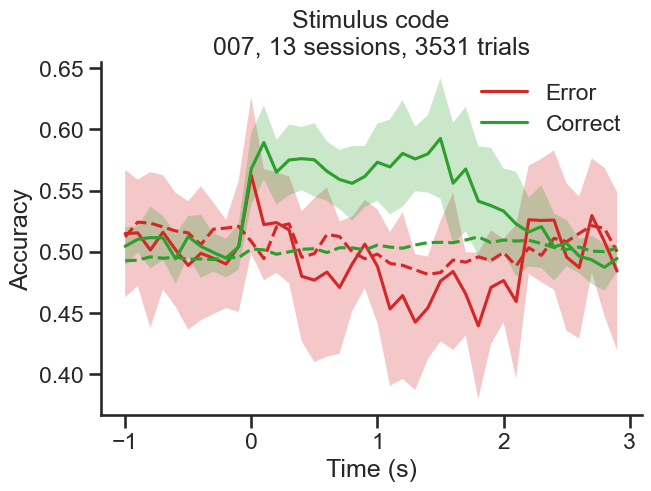

In [25]:
%%time
# Run mean epoch cross decoder split across sessions
# results_stim = mean_decoder(kind='epoch_split', epoch='stim', split_by='Hit', engagement=1, save=True)

# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_split_by_Hit.pkl'), 'rb') as f:
    results_stim = pickle.load(f)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim, errorbar='ci', z_null=True)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i][0].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Note the different mean null accuracy for both splits. This is correct.

Accuracy remains relatively stable around chance (~0.5) before stimulus onset (0s). A transient increase in decoding accuracy around 0s in correct trials, but no strong sustained difference between error and correct trials.
After ~1s, accuracy for correct trials trends slightly higher than for errors, but the separation is modest. For error trials the shuffles closely follow the downward trend of the code because in every error trial the animal licked to the opposite side of stimulus (what I am decoding).
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias.

In errors the stimulus is well represented, but the mouse prepare (delay) and execute (response) the wrong choice.

## Delay code split by Outcome (orange trace in mean epoch cross temporal decoder)

CPU times: total: 359 ms
Wall time: 369 ms


Text(0.5, 1.0, 'Delay code\n007, 13 sessions, 3531 trials')

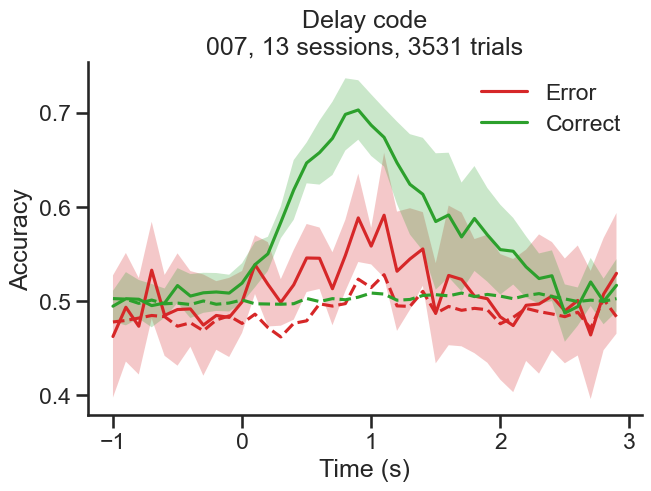

In [26]:
%%time
# Run mean epoch cross decoder split across sessions
# results_delay = mean_decoder(kind='epoch_split', epoch='delay', split_by='Hit', engagement=1, save=True)

# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_split_by_Hit.pkl'), 'rb') as f:
    results_delay = pickle.load(f)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay, epoch='delay', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_delay['acc'])
n_trials = np.sum([results_delay['acc'][i][0].shape[0] for i in range(len(results_delay['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Response code split by Outcome (green trace in mean epoch cross temporal decoder)

CPU times: total: 406 ms
Wall time: 404 ms


Text(0.5, 1.0, 'Response code\n007, 13 sessions, 3531 trials')

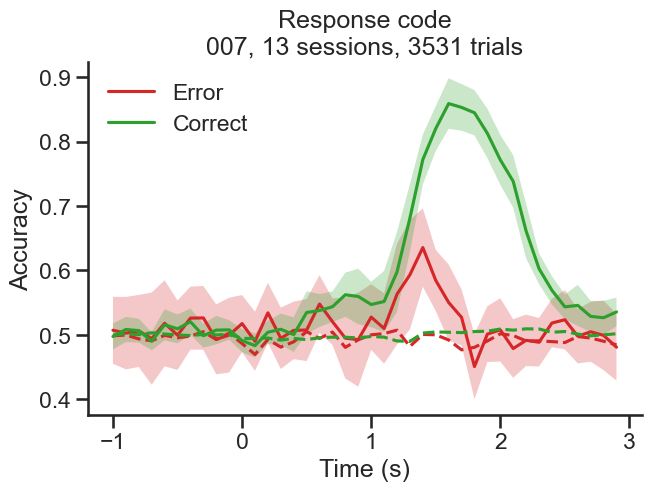

In [27]:
%%time
# Run mean epoch cross decoder split across sessions
# results_resp = mean_decoder(kind='epoch_split', epoch='resp', split_by='Hit', engagement=1, save=True)

# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_split_by_Hit.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp, epoch='resp', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_resp['acc'])
n_trials = np.sum([results_resp['acc'][i][0].shape[0] for i in range(len(results_resp['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Larger accuracy in correct trials because there is reward and therefore more licks.

# Engagement
Testing comparison of (stimulus) decoding accuracy of epoch cross decoder between engagement states (engaged vs disengaged)

## Stimulus

CPU times: total: 391 ms
Wall time: 381 ms


Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 7828 trials')

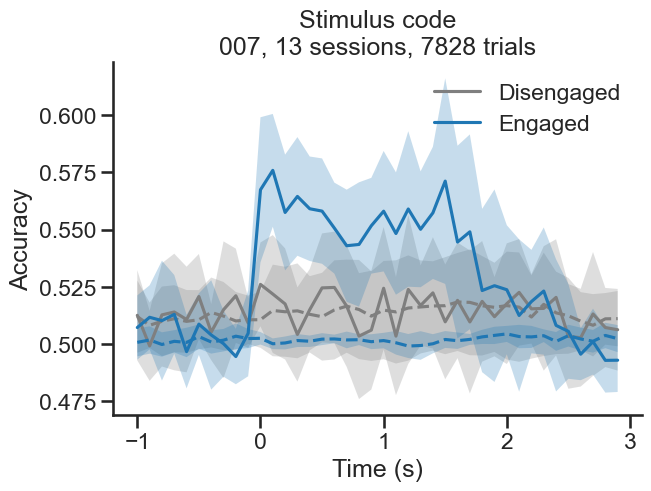

In [28]:
%%time
# Run mean epoch cross decoder split across sessions
# results_stim_disengaged = mean_decoder(kind='epoch', epoch='stim', engagement=0, save=True)
# results_stim_engaged = mean_decoder(kind='epoch', epoch='stim', engagement=1, save=True)

# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_disengaged.pkl'), 'rb') as f:
    results_stim_disengaged = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_engaged.pkl'), 'rb') as f:
    results_stim_engaged = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim_disengaged, epoch='stim', engagement=0, z_null=False)
plot_mean_epoch_cross_decoder(results_stim_engaged, epoch='stim', engagement=1, z_null=False)
n_sessions = len(results_stim_disengaged['acc'])
n_trials = np.sum([(results_stim_disengaged['acc'][i].shape[0] + results_stim_engaged['acc'][i].shape[0]) for i in range(len(results_stim_disengaged['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Delay

CPU times: total: 234 ms
Wall time: 257 ms


Text(0.5, 1.0, 'Delay code\n007, 13 sessions, 7828 trials')

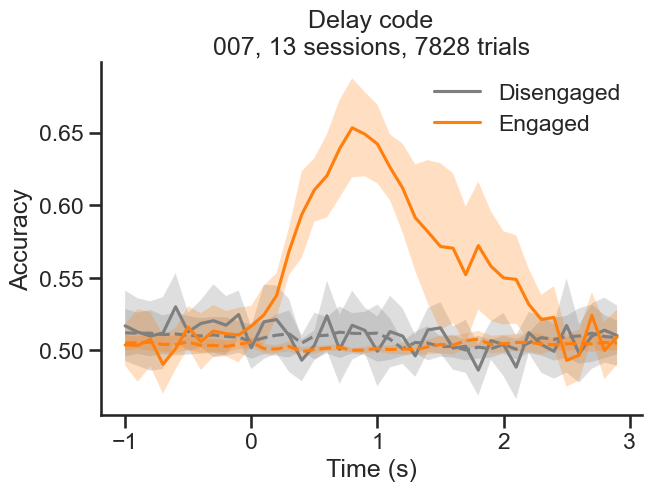

In [29]:
%%time
# Run mean epoch cross decoder split across sessions
# results_delay_disengaged = mean_decoder(kind='epoch', epoch='delay', engagement=0, save=True)
# results_delay_engaged = mean_decoder(kind='epoch', epoch='delay', engagement=1, save=True)

# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_disengaged.pkl'), 'rb') as f:
    results_delay_disengaged = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_engaged.pkl'), 'rb') as f:
    results_delay_engaged = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_delay_disengaged, epoch='delay', engagement=0, z_null=False)
plot_mean_epoch_cross_decoder(results_delay_engaged, epoch='delay', engagement=1, z_null=False)
n_sessions = len(results_delay_disengaged['acc'])
n_trials = np.sum([(results_delay_disengaged['acc'][i].shape[0] + results_delay_engaged['acc'][i].shape[0]) for i in range(len(results_delay_disengaged['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Response

CPU times: total: 266 ms
Wall time: 278 ms


Text(0.5, 1.0, 'Response code\n007, 13 sessions, 7828 trials')

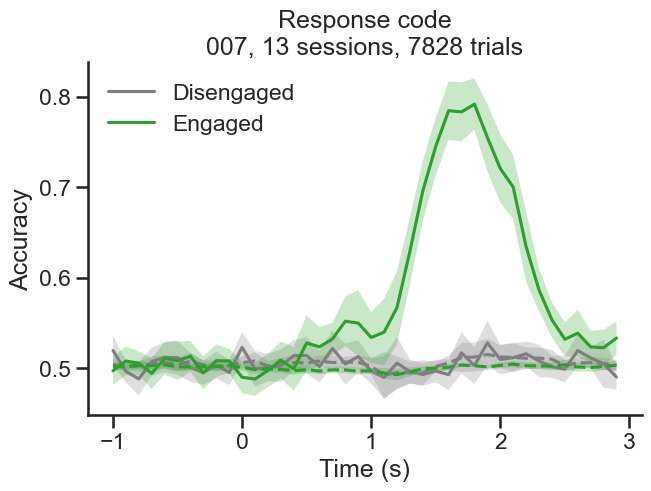

In [30]:
%%time
# Run mean epoch cross decoder split across sessions
# results_resp_disengaged = mean_decoder(kind='epoch', epoch='resp', engagement=0, save=True)
# results_resp_engaged = mean_decoder(kind='epoch', epoch='resp', engagement=1, save=True)

# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_disengaged.pkl'), 'rb') as f:
    results_resp_disengaged = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_engaged.pkl'), 'rb') as f:
    results_resp_engaged = pickle.load(f)

# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_resp_disengaged, epoch='resp', engagement=0, z_null=False)
plot_mean_epoch_cross_decoder(results_resp_engaged, epoch='resp', engagement=1, z_null=False)
n_sessions = len(results_resp_disengaged['acc'])
n_trials = np.sum([(results_resp_disengaged['acc'][i].shape[0] + results_resp_engaged['acc'][i].shape[0]) for i in range(len(results_resp_disengaged['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Train in correct trials, test in error trials

### All trials

In [ ]:
%%time
results_all_trials = mean_decoder(kind='test', epoch='stim', split_by='Hit', engagement=None, save=False)

plot_mean_epoch_cross_decoder_split(results_all_trials, z_null=True)
n_sessions = len(results_all_trials['acc'])
n_trials = np.sum([results_all_trials['acc'][i][0].shape[0] for i in range(len(results_all_trials['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

### Engaged trials only

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
epoch_cross_decoder_split_TEST took 0.49 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
epoch_cross_decoder_split_TEST took 0.50 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
epoch_cross_decoder_split_TEST took 0.68 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
epoch_cross_decoder_split_TEST took 0.52 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
epoch_cross_decoder_split_TEST took 0.63 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
epoch_cross_decoder_split_TEST took 0.46 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
epoch_cross_decoder_split_TEST took 0.54 seconds

Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 3531 trials')

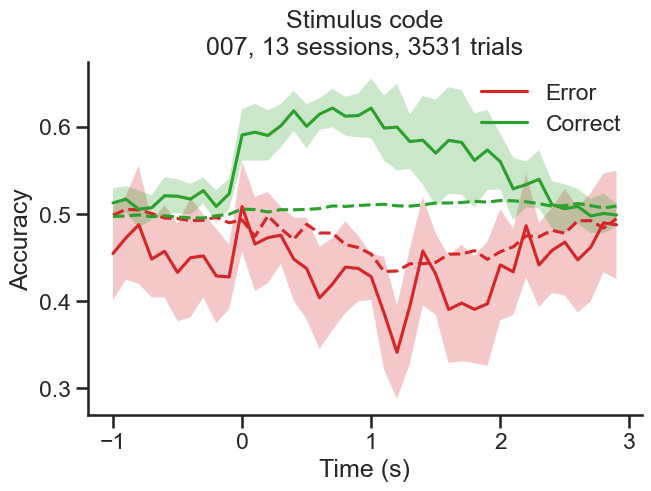

In [31]:
%%time
# Run mean epoch cross decoder split across sessions
results_stim_engaged = mean_decoder(kind='test', epoch='stim', split_by='Hit', engagement=1, n_shuffles=100, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim_engaged, epoch='stim', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_stim_engaged['acc'])
n_trials = np.sum([results_stim_engaged['acc'][i][0].shape[0] for i in range(len(results_stim_engaged['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
epoch_cross_decoder_split_TEST took 1.87 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
epoch_cross_decoder_split_TEST took 2.02 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
epoch_cross_decoder_split_TEST took 2.44 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
epoch_cross_decoder_split_TEST took 1.92 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
epoch_cross_decoder_split_TEST took 2.37 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
epoch_cross_decoder_split_TEST took 2.11 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
epoch_cross_decoder_split_TEST took 2.04 seconds

Text(0.5, 1.0, 'Delay code\n007, 13 sessions, 3531 trials')

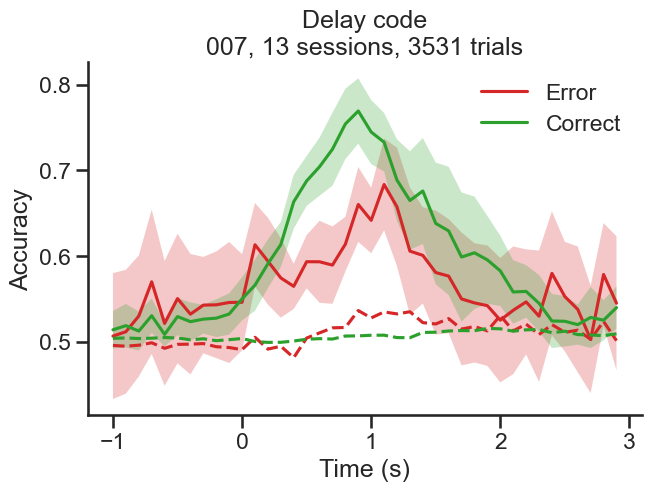

In [32]:
%%time
# Run mean epoch cross decoder split across sessions
results_delay_engaged = mean_decoder(kind='test', epoch='delay', split_by='Hit', engagement=1, n_shuffles=1000, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay_engaged, epoch='delay', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_stim_engaged['acc'])
n_trials = np.sum([results_delay_engaged['acc'][i][0].shape[0] for i in range(len(results_delay_engaged['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
epoch_cross_decoder_split_TEST took 1.91 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
epoch_cross_decoder_split_TEST took 2.13 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
epoch_cross_decoder_split_TEST took 2.44 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
epoch_cross_decoder_split_TEST took 2.54 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
epoch_cross_decoder_split_TEST took 2.77 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
epoch_cross_decoder_split_TEST took 2.75 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
epoch_cross_decoder_split_TEST took 2.42 seconds

Text(0.5, 1.0, 'Response code\n007, 13 sessions, 3531 trials')

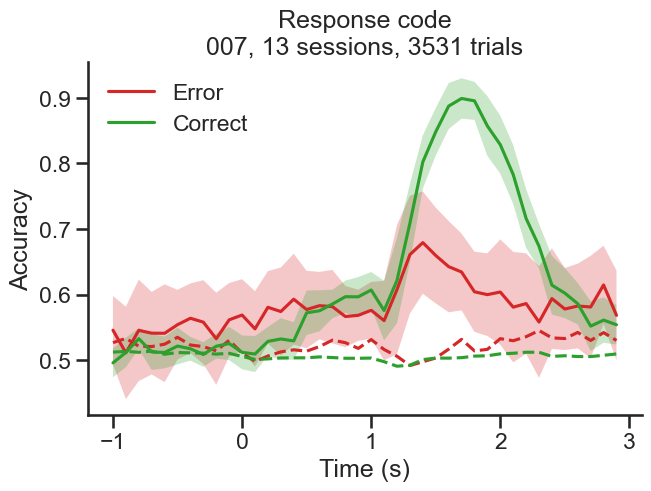

In [33]:
%%time
# Run mean epoch cross decoder split across sessions
results_resp_engaged = mean_decoder(kind='test', epoch='resp', split_by='Hit', engagement=1, n_shuffles=1000, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp_engaged, epoch='resp', split='hit', errorbar='ci', z_null=True)
n_sessions = len(results_resp_engaged['acc'])
n_trials = np.sum([results_resp_engaged['acc'][i][0].shape[0] for i in range(len(results_resp_engaged['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Train in correct engaged trials, test in correct disengaged trials

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
epoch_cross_decoder_split_TEST took 0.71 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
epoch_cross_decoder_split_TEST took 0.62 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
epoch_cross_decoder_split_TEST took 1.03 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
epoch_cross_decoder_split_TEST took 1.03 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
epoch_cross_decoder_split_TEST took 0.97 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
epoch_cross_decoder_split_TEST took 0.67 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
epoch_cross_decoder_split_TEST took 1.23 seconds

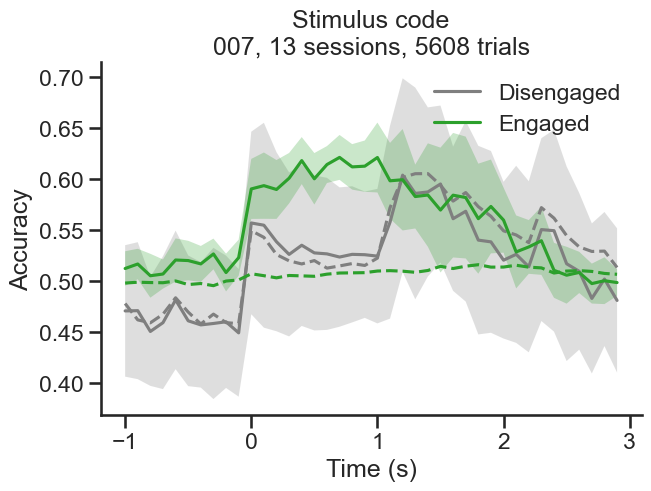

In [34]:
%%time
# Run mean epoch cross decoder split across sessions
results_stim_correct = mean_decoder(kind='test', epoch='stim', split_by='Engaged', engagement=None, drop_miss=False, hit_only=True, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim_correct, errorbar='ci', split='engagement', z_null=True)
n_sessions = len(results_stim_correct['acc'])
n_trials = np.sum([results_stim_correct['acc'][i][0].shape[0] for i in range(len(results_stim_correct['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')
plt.legend(frameon=False)

Processing session 1/13: 007_2024-06-22_10-48-57...
Files exist in folder. Skipping
Processing session 2/13: 007_2024-06-23_12-46-55...
Files exist in folder. Skipping
Processing session 3/13: 007_2024-06-24_17-47-22...
Files exist in folder. Skipping
Processing session 4/13: 007_2024-06-25_15-54-23...
Files exist in folder. Skipping
Processing session 5/13: 007_2024-06-26_15-19-30...
Files exist in folder. Skipping
Processing session 6/13: 007_2024-06-27_15-06-28...
Files exist in folder. Skipping
Processing session 7/13: 007_2024-06-28_14-18-51...
Files exist in folder. Skipping
Processing session 8/13: 007_2024-06-29_16-24-52...
Files exist in folder. Skipping
Processing session 9/13: 007_2024-07-08_12-20-29...
Files exist in folder. Skipping
Processing session 10/13: 007_2024-07-09_12-10-57...
Files exist in folder. Skipping
Processing session 11/13: 007_2024-07-10_12-03-35...
Files exist in folder. Skipping
Processing session 12/13: 007_2024-07-11_12-39-21...
Files exist in folder

Text(0.5, 1.0, 'Delay code\n007, 13 sessions, 5608 trials')

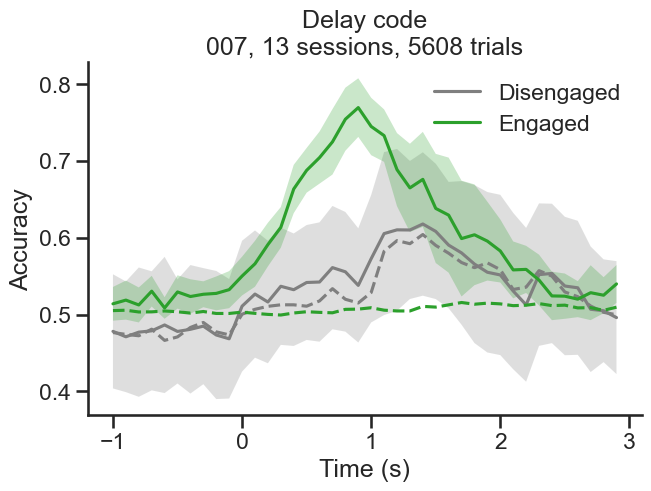

In [37]:
%%time
# Run mean epoch cross decoder split across sessions
results_delay_correct = mean_decoder(kind='test', epoch='delay', split_by='Engaged', engagement=None, drop_miss=False, hit_only=True, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay_correct, errorbar='ci', split='engagement', z_null=True)
n_sessions = len(results_delay_correct['acc'])
n_trials = np.sum([results_delay_correct['acc'][i][0].shape[0] for i in range(len(results_delay_correct['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
epoch_cross_decoder_split_TEST took 0.85 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
epoch_cross_decoder_split_TEST took 0.59 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
epoch_cross_decoder_split_TEST took 0.85 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
epoch_cross_decoder_split_TEST took 0.79 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
epoch_cross_decoder_split_TEST took 0.78 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
epoch_cross_decoder_split_TEST took 0.71 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
epoch_cross_decoder_split_TEST took 0.97 seconds

Text(0.5, 1.0, 'Response code\n007, 13 sessions, 5608 trials')

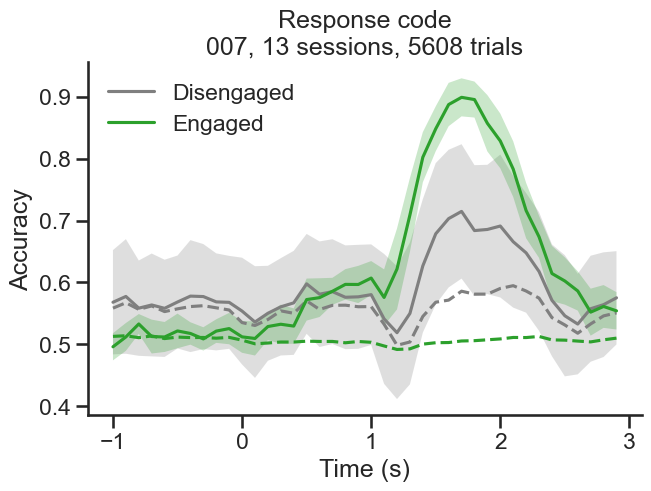

In [38]:
%%time
# Run mean epoch cross decoder split across sessions
results_resp_correct = mean_decoder(kind='test', epoch='resp', split_by='Engaged', engagement=None, drop_miss=False, hit_only=True, save=False)

# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp_correct, errorbar='ci', split='engagement', z_null=True)
n_sessions = len(results_resp_correct['acc'])
n_trials = np.sum([results_resp_correct['acc'][i][0].shape[0] for i in range(len(results_resp_correct['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Population selectivity analysis

From:
Inagaki, H. K., Chen, S., Ridder, M. C., Sah, P., Li, N., Yang, Z., Hasanbegovic, H., Gao, Z., Gerfen, C. R., & Svoboda, K. (2022). A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement. Cell, 185(6), 1065-1081.e23. https://doi.org/10.1016/j.cell.2022.02.006

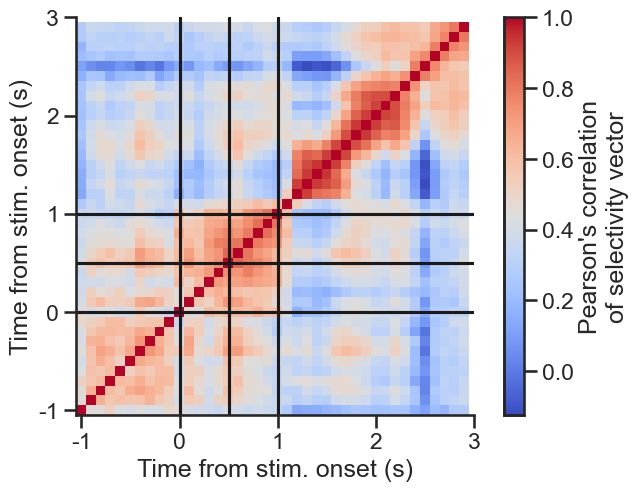

In [29]:
# Align to stimulus onset
df_behavior = behavior[0]
bins = np.load(folder_parent / ephys_ids[0] / 'bins.npy')
all_psth = np.load(folder_parent / ephys_ids[0] / 'all_psth.npy')

# Step 1: Separate trials by condition
left_lick_trials = df_behavior[df_behavior.Choice == 0].Trial
right_lick_trials = df_behavior[df_behavior.Choice == 1].Trial

# Step 2: Compute mean firing rates per time bin
r_lick_left = np.mean(all_psth[left_lick_trials], axis=0)  # shape (bins, neurons)
r_lick_right = np.mean(all_psth[right_lick_trials], axis=0)  # shape (bins, neurons)

# Step 3: Compute selectivity vector w_t
wt = r_lick_right - r_lick_left  # shape (bins, neurons)

# Step 4: Perform SVD to get the dominant coding direction
U, S, Vt = np.linalg.svd(wt, full_matrices=False)

# Step 5: CD_delay is the first right singular vector (principal axis)
CD_delay = Vt[0, :]  # First singular vector (neurons,)

# Step 6: Normalize to unit vector
CD_delay /= np.linalg.norm(CD_delay)

# Step 7: Compute correlation matrix
corr_matrix = np.corrcoef(wt)
# np.fill_diagonal(corr_matrix, np.nan)  # Remove diagonal by setting it to NaN

# Step 8: Plot correlation matrix
plt.figure(constrained_layout=True)
plt.imshow(corr_matrix, cmap='coolwarm', origin='lower')
plt.axhline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axvline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axhline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axvline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axhline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.axvline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.xticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.yticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.colorbar(label="Pearson's correlation\nof selectivity vector")
plt.xlabel('Time from stim. onset (s)')
plt.ylabel('Time from stim. onset (s)')
# plt.title('Correlation of Population Selectivity Over Time')
sns.despine()

Pearson's correlation is high during the delay epoch (0.5-1 s), meaning that a similar subpopulation of neurons holds selectivity during motor planning. In contrast, population selectivity show a low correlation before and after the Go cue (1 s), meaning that different subpopulations of neurons show selectivity. Population activity patterns in M2 change rapidly before and during movement initiation.